# Analysis module tour

A guided tour of `mm_pipeline.analysis`, the data analysis module. It complements `example2.ipynb` (the end-to-end pipeline demo): here the focus is the `Lineage` model, branch **selectors**, **plots**, per-cell **properties**, cycle **metrics**, the **CLI**, and **interactive** branch selection.

## 0 · Setup

Wrap a quick DP-baseline reconstruction in a `Lineage`. We set `frame_interval_min` so time axes are in minutes and `cycle_time` is minute-valued.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from mm_pipeline.config.schemas import DatasetSpec
from mm_pipeline.runners import run_track_generate, run_track_select
from mm_pipeline.analysis import (
    Lineage, TrackSet,
    mother_branch, descendants_of, ancestors_of, roots, leaves, generation, filter_cycles, path_between,
    plot_swimlane, plot_dendrogram, plot_property_series,
    cell_properties,
    metrics, cycle_metric, list_cycle_metrics,
    pick_tracks,
)

EXAMPLE_DATA = Path("../example_data")

ds = DatasetSpec(
    dataset_id="symbac_vid2",
    labels_dir=EXAMPLE_DATA / "labels",
    axis="y",
    open_end="high",
    frame_interval_min=0.25,   # minutes on the time axes
)

# A quick DP baseline reconstruction (a few seconds; no scorer training).
cand = run_track_generate(ds, top_k=16)
sel = run_track_select(ds, candidates=cand.candidates_df, scorer="dp_cost_min")
lin = Lineage.from_result(sel, ds)
print(f"{lin.dataset_id}: {len(lin.frames_by_track)} tracks, {len(lin.child_map)} divisions")

symbac_vid2: 43 tracks, 20 divisions


## 1 · The `Lineage` model & the cycles table

One row per `track_id`, which is one cell cycle (birth to division). The selectors and metrics build on this table.

In [20]:
print("cycles shape:", lin.cycles.shape)
lin.cycles.head(12)

cycles shape: (43, 11)


,dataset_id,track_id,parent_id,generation,birth_t,end_t,n_frames,n_gap_frames,birth_observed,end_cause,complete_cycle
0,symbac_vid2,1,<NA>,0,0,23,24,0,False,exited,False
1,symbac_vid2,2,<NA>,0,0,33,34,0,False,divided,False
2,symbac_vid2,3,<NA>,0,0,35,36,0,False,divided,False
3,symbac_vid2,4,2,1,34,66,33,0,True,exited,False
4,symbac_vid2,5,2,1,34,105,72,0,True,exited,False
5,symbac_vid2,6,3,1,36,117,82,0,True,divided,True
6,symbac_vid2,7,3,1,36,115,80,0,True,divided,True
7,symbac_vid2,8,7,2,116,191,76,0,True,divided,True
8,symbac_vid2,9,7,2,116,196,81,0,True,divided,True
9,symbac_vid2,10,6,2,118,147,30,0,True,exited,False


In [21]:
# `complete_cycle` = observed birth AND division AND no time gaps
# for interdivision statistics (a generation-time histogram over these is unbiased).
complete = lin.cycles[lin.cycles["complete_cycle"]]
print(f"{len(complete)} of {len(lin.cycles)} tracks are complete cycles")
complete.head()

18 of 43 tracks are complete cycles


,dataset_id,track_id,parent_id,generation,birth_t,end_t,n_frames,n_gap_frames,birth_observed,end_cause,complete_cycle
5,symbac_vid2,6,3,1,36,117,82,0,True,divided,True
6,symbac_vid2,7,3,1,36,115,80,0,True,divided,True
7,symbac_vid2,8,7,2,116,191,76,0,True,divided,True
8,symbac_vid2,9,7,2,116,196,81,0,True,divided,True
13,symbac_vid2,14,9,3,197,277,81,0,True,divided,True


## 2 · Selectors & set algebra

Selectors are plain functions returning a `TrackSet` (a named, dataset-scoped set of `track_id`s). Compose them with `|`, `&`, `-`.

In [23]:
branch = mother_branch(lin)
print("mother_branch:", sorted(branch))
print("roots:       ", sorted(roots(lin)))
print("leaves:      ", sorted(leaves(lin)))
print("generation 2:", sorted(generation(lin, 2)))

# Subtree / ancestry from a track partway down the mother branch.
tid = sorted(branch)[len(branch) // 2]
print(f"descendants_of({tid}):", sorted(descendants_of(lin, tid)))
print(f"ancestors_of({tid}):  ", sorted(ancestors_of(lin, tid)))

# filter_cycles takes any predicate over the cycles table.
divided = filter_cycles(lin, lambda c: c["end_cause"] == "divided", name="divided")
print(f"{divided.name}: {len(divided)} tracks")

mother_branch: [3, 7, 9, 15, 17, 21, 27, 29, 33, 39, 43]
roots:        [1, 2, 3]
leaves:       [1, 4, 5, 10, 11, 12, 13, 18, 19, 22, 23, 24, 25, 30, 31, 34, 35, 36, 37, 40, 41, 42, 43]
generation 2: [8, 9, 10, 11]
descendants_of(21): [21, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]
ancestors_of(21):   [3, 7, 9, 15, 17]
divided: 20 tracks


In [24]:
# Set algebra (dataset_id-guarded), and resolving a TrackSet back to lineage rows.
non_mother = descendants_of(lin, tid) - branch
print("descendants of", tid, "minus the mother branch:", sorted(non_mother))
print("roots | leaves size:", len(roots(lin) | leaves(lin)))

branch.cycles(lin)[["track_id", "generation", "end_cause", "complete_cycle"]]

descendants of 21 minus the mother branch: [26, 28, 30, 31, 32, 34, 35, 36, 37, 38, 40, 41, 42]
roots | leaves size: 25


,track_id,generation,end_cause,complete_cycle
2,3,0,divided,False
6,7,1,divided,True
8,9,2,divided,True
14,15,3,divided,True
16,17,4,divided,True
20,21,5,divided,True
26,27,6,divided,True
28,29,7,divided,True
32,33,8,divided,True
38,39,9,divided,True


In [25]:
# The dataset_id guard: a selection from one lineage can't be silently applied to another (track_ids restart at 1 per dataset).
other = TrackSet("some_other_dataset", frozenset({1, 2}))
try:
    branch | other
except ValueError as exc:
    print("blocked:", exc)

blocked: Cannot combine TrackSets from 'symbac_vid2' and 'some_other_dataset'.


## 3 · Plots

Every plotter takes a `Lineage` (+ optional `TrackSet` to highlight), returns the `Axes`, and tags one line per track. The **swimlane** is the spatial view; the **dendrogram** is the genealogy view.

<Axes: title={'center': 'symbac_vid2 — lineage dendrogram (43 tracks, gen 0..10)'}, xlabel='time (min)', ylabel='lineage layout (one band per subtree)'>

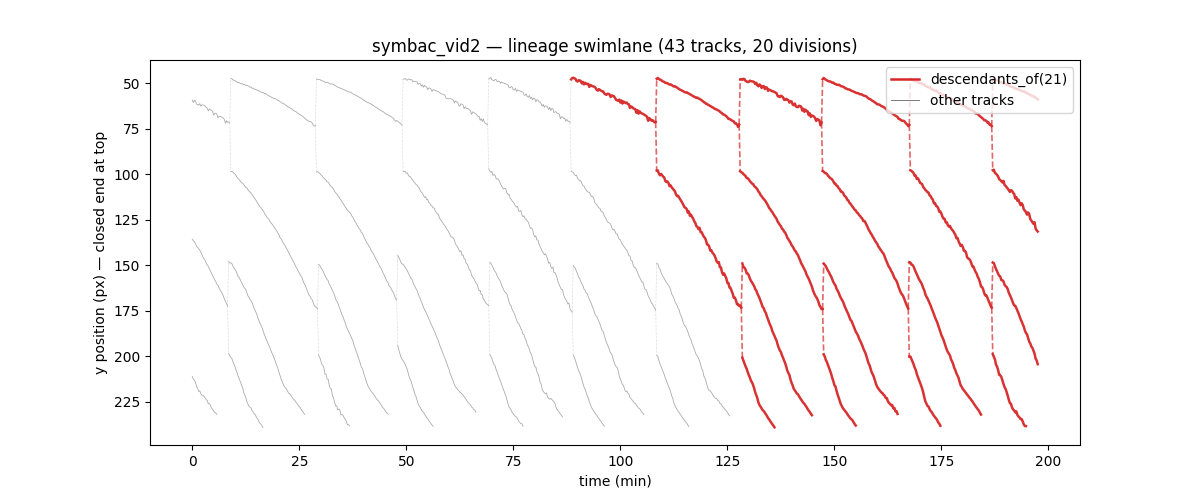

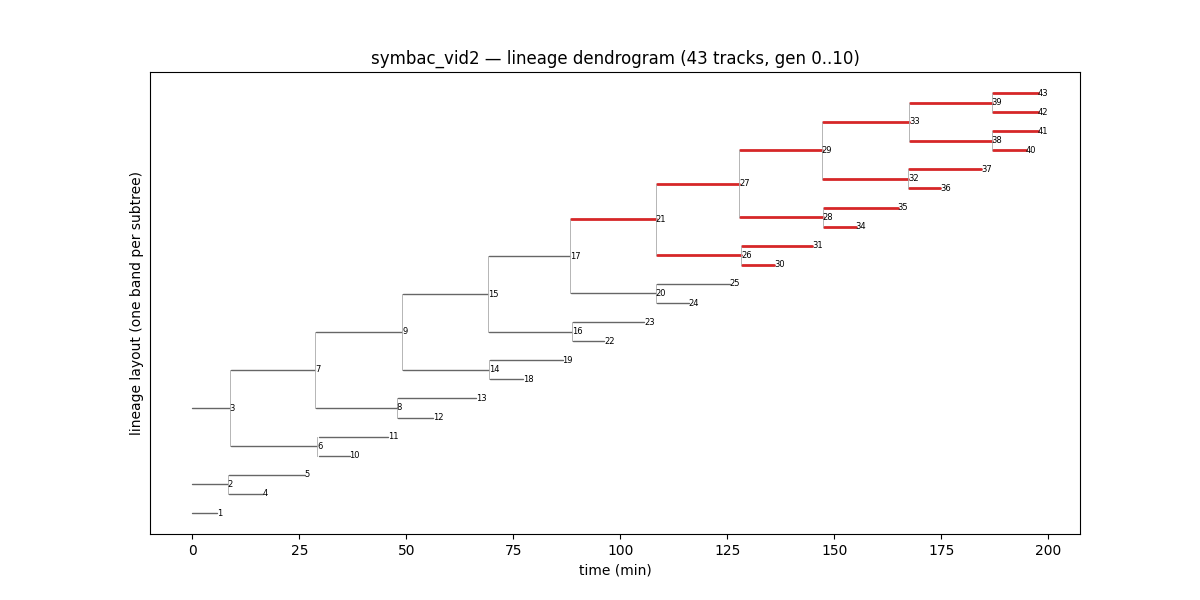

In [29]:
subtree = descendants_of(lin, tid)
plot_swimlane(lin, highlight=subtree)
plot_dendrogram(lin, highlight=subtree)

<Axes: title={'center': 'symbac_vid2 — mother_branch: axis_len (11 cell cycles)'}, xlabel='time (min)', ylabel='axis_len (px)'>

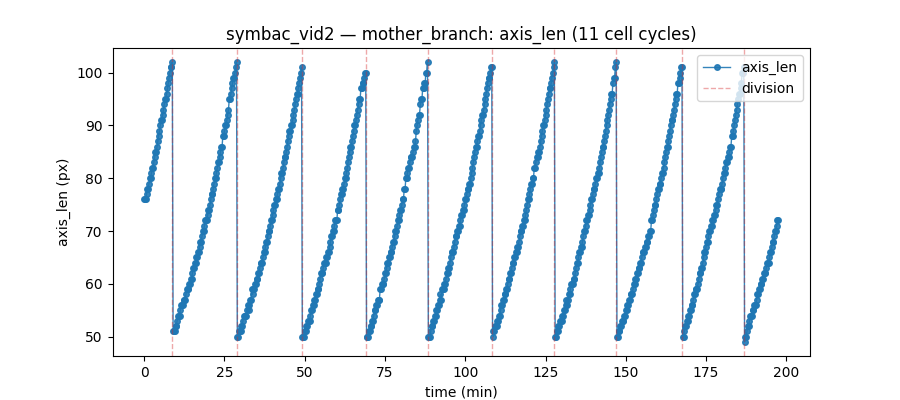

In [31]:
# We might want to plot a time-series of some cell property. This is an example with length of mother cell. 
# X-axis is minutes because frame_interval_min is set.
# the line breaks at any time gap (bridged frames), and divisions are marked.
plot_property_series(lin, branch, prop="axis_len")

## 4 · Per-cell properties (regionprops)

`cell_properties` runs scikit-image `regionprops` over the label images and joins on `(t, label)`, giving a *fitted* length (`major_axis_length_px`) and shape descriptors. Passing a `TrackSet` keeps it cheap.

In [33]:
props = cell_properties(lin, branch)
print("columns:", list(props.columns))
props.head()

columns: ['dataset_id', 'track_id', 't', 'label', 'major_axis_length_px', 'orientation', 'eccentricity', 'solidity', 'bbox_len', 'area']


,dataset_id,track_id,t,label,major_axis_length_px,orientation,eccentricity,solidity,bbox_len,area
0,symbac_vid2,3,0,1,83.548745,-0.089143,0.980907,0.927093,76.0,1030.0
1,symbac_vid2,3,1,1,84.492338,-0.094768,0.979538,0.926146,76.0,1091.0
2,symbac_vid2,3,2,1,84.525266,-0.088835,0.981202,0.927176,76.0,1044.0
3,symbac_vid2,3,3,1,85.542838,-0.088311,0.981721,0.924628,77.0,1055.0
4,symbac_vid2,3,4,1,86.846320,-0.091937,0.980624,0.925681,78.0,1121.0


added column present: True


<Axes: title={'center': 'symbac_vid2 — mother_branch: major_axis_length_px (11 cell cycles)'}, xlabel='time (min)', ylabel='major_axis_length_px (px)'>

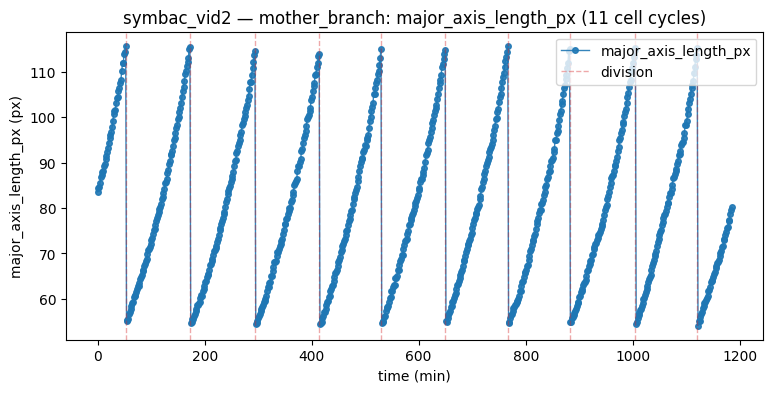

In [ ]:
# Extensibility is skimage's own extra_properties
# If you want your own property, just define any function that takes a regionmask and reutrns a scalar 
def filled_fraction(regionmask):
    return float(regionmask.sum()) / float(regionmask.size)

props_plus = cell_properties(lin, branch, extra_properties=(filled_fraction,))
print("added column present:", "filled_fraction" in props_plus.columns)

# Plot the *fitted* length via the data= seam 
plot_property_series(lin, branch, prop="major_axis_length_px", data=props)

## 5 · Cycle metrics

A registry of per-cycle reductions driven by an explicit `CycleContext`. A metric returns a scalar or a dict (expanded into columns). Metrics that read properties need `with_properties=True`.

In [11]:
print("available metrics:", list_cycle_metrics())

complete_set = filter_cycles(lin, lambda c: c["complete_cycle"], name="complete")
table = metrics(
    lin, complete_set,
    ["cycle_time", "birth_length", "added_length", "growth_rate"],
    with_properties=True,
)
table[["track_id", "generation", "cycle_time", "birth_length", "added_length",
       "growth_rate", "growth_rate_r2", "growth_rate_n"]]

available metrics: ['added_length', 'birth_length', 'cycle_time', 'growth_rate']


,track_id,generation,cycle_time,birth_length,added_length,growth_rate,growth_rate_r2,growth_rate_n
0,6,1,123.0,55.504571,60.234698,0.005987,0.999020,82
1,7,1,120.0,55.093564,60.396458,0.006203,0.999230,80
2,8,2,114.0,55.143073,60.847315,0.006621,0.998755,76
3,9,2,121.5,54.608908,59.825002,0.006201,0.999336,81
4,14,3,121.5,54.456494,63.357299,0.006079,0.996943,81
5,15,3,120.0,54.529617,59.335818,0.006267,0.999458,80
6,16,4,118.5,54.951633,58.779218,0.006168,0.999031,79
7,17,4,115.5,54.531948,60.440134,0.006512,0.999556,77
8,20,5,120.0,54.851214,59.695789,0.006012,0.999289,80
9,21,5,120.0,54.675679,60.011663,0.006226,0.999318,80


 track_id  max_length
        6  115.739269
        7  115.490022
        8  115.990387
        9  114.433909
       14  117.813793


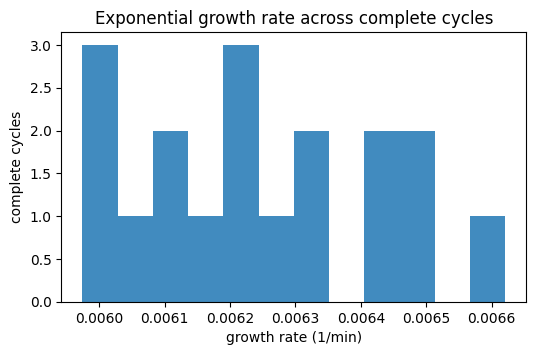

In [ ]:
# Extend by writing one function: register a new metric with @cycle_metric
@cycle_metric("max_length")
def max_length(ctx):
    return float(ctx.properties["major_axis_length_px"].max())

table2 = metrics(lin, complete_set, ["max_length"], with_properties=True)
print(table2[["track_id", "max_length"]].head().to_string(index=False))

# Distribution of exponential growth rate across complete cycles
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(table["growth_rate"].dropna(), bins=12, color="#1f77b4", alpha=0.85)
ax.set_xlabel("growth rate (1/min)")
ax.set_ylabel("complete cycles")
ax.set_title("Exponential growth rate across complete cycles")
plt.show()

## 6 · The `analyse` CLI

The headless equivalent: from a reconstructed run it writes `cycles.csv` (+ requested metrics) and `swimlane.png` / `dendrogram.png`. Here is its interface (a full run needs a run directory + manifest).

In [13]:
from mm_pipeline.cli.main import main

try:
    main(["analyse", "--help"])
except SystemExit:
    pass

usage: mm-pipeline analyse [-h] --run RUN --dataset DATASET --manifest
                           MANIFEST [--metrics METRICS] [--out OUT]
                           [--overwrite] [-v]

Cycles, optional cycle metrics, and swimlane/dendrogram plots from a
reconstructed run (track-select / modelvio)

options:
  -h, --help           show this help message and exit
  --run RUN            Run directory (<out>/<run_tag>).
  --dataset DATASET    Dataset id within the run.
  --manifest MANIFEST  Path to a dataset manifest CSV/YAML.
  --metrics METRICS    Comma-separated cycle metrics, e.g.
                       cycle_time,growth_rate.
  --out OUT            Output directory (default: <run>/<dataset>/analysis).
  --overwrite          Allow overwriting existing outputs.
  -v, --verbose


## 7 · Interactive branch selection  ⚠️ needs `ipympl`

Pick a **branch** (a lineage path) with **two clicks**: click the start cell, then the end (e.g. a leaf).
The selection is the unique path between them (`path_between`), a single chain ready for time-series
analysis. The plot gives live feedback: the first click highlights the start, the second
highlights the whole branch, and it is stored on `picker.selection`. 


This needs an interactive backend. If `ipympl` isn't installed, run the install cell, **restart the
kernel**, and re-run from the top. 

In [34]:
# Backend installation cell: run this then restart the kernel if ipympl is not installed
# %pip install ipympl

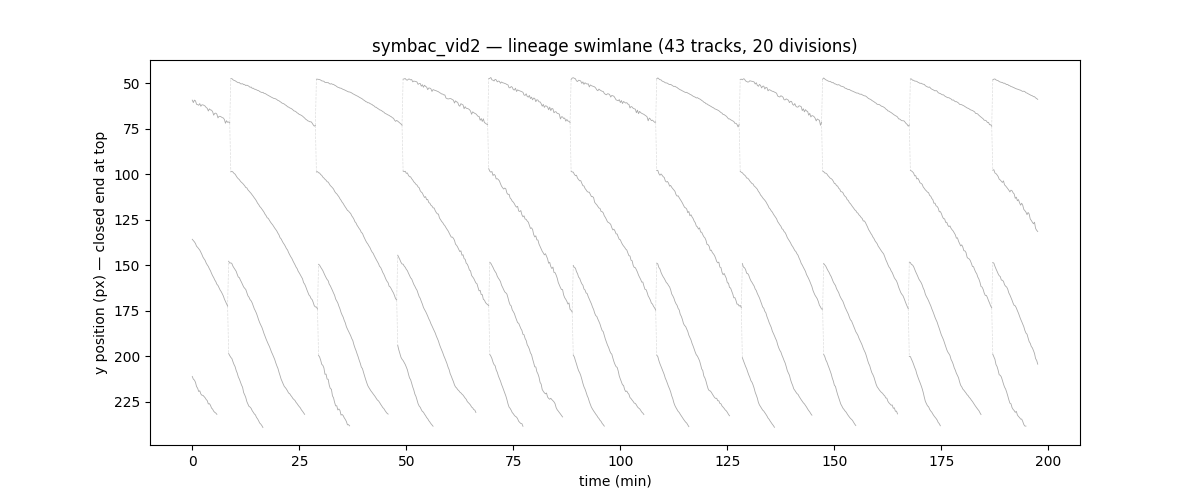

In [37]:
# Switch to an interactive backend, draw a swimlane, and attach the two-click branch picker.
%matplotlib widget
ax = plot_swimlane(lin)
picker = pick_tracks(lin, ax)
# Click the START of a branch, then its END (e.g. a leaf). The branch highlights in place and
# `picker.selection` becomes path_between(lin, start, end). Works on the dendrogram too:
#     pick_tracks(lin, plot_dendrogram(lin))

branch: [7, 9, 15, 17, 21, 27, 28, 35]


<Axes: title={'center': 'symbac_vid2 — path_between(7, 35): axis_len (8 cell cycles)'}, xlabel='time (min)', ylabel='axis_len (px)'>

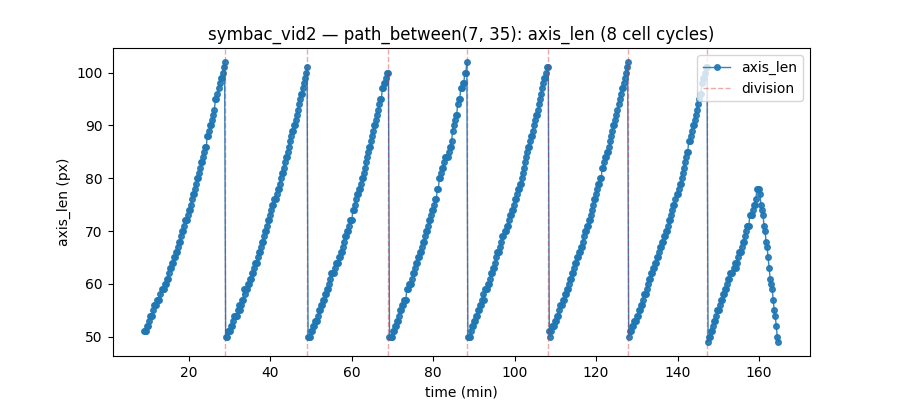

In [ ]:
# Use the picked branch for analysis. Falls back to a declarative branch (the mother
# lineage as a start -> end path) so this renders without an interactive click
mb = sorted(mother_branch(lin))
branch = picker.selection if ("picker" in dir() and picker.selection) else path_between(lin, mb[0], mb[-1])
print("branch:", sorted(branch))
plot_property_series(lin, branch, prop="axis_len")